In [2]:
import pandas as pd

df = pd.read_csv('Sales1.csv')

print(df.head())

  OrderID CustomerID Product  Quantity  Price   OrderDate
0   O1001       C001  Laptop         2  55000  2023-04-10
1   O1002       C002  Mobile         1  25000  2023-04-12
2   O1003       C003  Tablet         3  15000  2023-05-01
3   O1004       C004  Laptop         1  60000  2023-05-15
4   O1005       C005  Mobile         2  22000  2023-06-05


In [ ]:
# FILTERING: Get all orders where Quantity is greater than 1
filtered_df = df[df['Quantity'] > 1]
print(filtered_df)

  OrderID CustomerID     Product  Quantity  Price   OrderDate
0   O1001       C001      Laptop         2  55000  2023-04-10
2   O1003       C003      Tablet         3  15000  2023-05-01
4   O1005       C005      Mobile         2  22000  2023-06-05
5   O1006       C006  Headphones         5   2000  2023-06-10
7   O1008       C008      Tablet         2  18000  2023-07-20


In [6]:
# GROUPING: Calculate the total quantity sold for each product
grouped_df = df.groupby('Product')['Quantity'].sum().reset_index()
print(grouped_df)

      Product  Quantity
0  Headphones         5
1      Laptop         4
2      Mobile         3
3      Tablet         5


In [ ]:
# SORTING: Sort the products by total quantity sold
sorted_df = grouped_df.sort_values(by='Quantity', ascending=False)
print(sorted_df)

      Product  Quantity
0  Headphones         5
3      Tablet         5
1      Laptop         4
2      Mobile         3


In [8]:
# Insight 1: Find the best-selling product by volume
top_product = sorted_df.iloc[0]['Product']
top_quantity = sorted_df.iloc[0]['Quantity']

# Insight 2: Calculate average price for Laptops (High-ticket item analysis)
avg_laptop_price = df[df['Product'] == 'Laptop']['Price'].mean()

print(top_product)
print(top_quantity)
print(avg_laptop_price)

Headphones
5
57666.666666666664


## Data Visualization

Bar chart created and saved as 'bar_chart.png'.
Line chart created and saved as 'line_chart.png'.


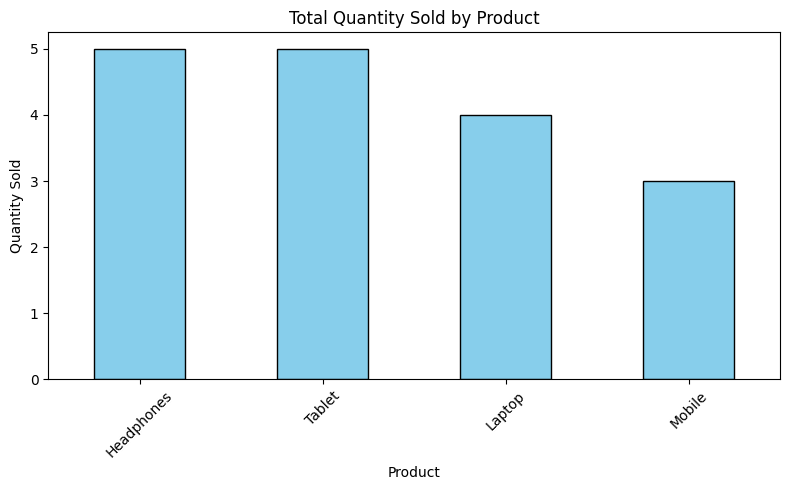

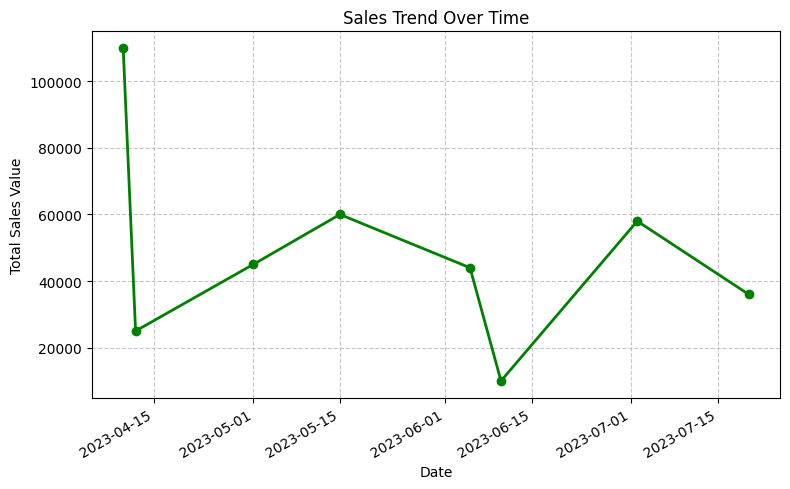

In [10]:
import matplotlib.pyplot as plt

#Bar chart

df['Total_Sales'] = df['Quantity'] * df['Price']
df['OrderDate'] = pd.to_datetime(df['OrderDate'])

# We will visualize 'Total Quantity Sold per Product'
plt.figure(figsize=(8, 5))
product_qty = df.groupby('Product')['Quantity'].sum().sort_values(ascending=False)
product_qty.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Total Quantity Sold by Product')
plt.xlabel('Product')
plt.ylabel('Quantity Sold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('bar_chart.png') 
print("Bar chart created and saved as 'bar_chart.png'.")


#Line Chart 

# We will visualize the 'Sales Trend Over Time'
plt.figure(figsize=(8, 5))
sales_trend = df.groupby('OrderDate')['Total_Sales'].sum()
sales_trend.plot(kind='line', marker='o', color='green', linewidth=2)
plt.title('Sales Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Total Sales Value')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('line_chart.png')
print("Line chart created and saved as 'line_chart.png'.")


